In [1]:
import h5py
import numpy as np
import json

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.which'] = 'both'
mpl.rcParams['grid.color'] = 'grey'
mpl.rcParams['grid.alpha'] = 0.2
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.handlelength'] = 3
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True      # show ticks on the top axis
mpl.rcParams['ytick.right'] = True    # show ticks on the right axis

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [2]:
file_path = "network_bbh_CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_LIA+_10.0hz.h5" 

with h5py.File(file_path, 'r') as f:
    
    # Reading Fisher results
    snr_net = f['snr'][:]
    fisher_net = f['fisher'][:]
    Cov_dL = f['covariance'][:]
    eps_dL = f['inversion_errors'][:]
    my_sky_area_90 = f['sky_area_90'][:]
    cond_numbers = f['condition_numbers'][:]
    inband_matrix = f['is_in_band'][:]
    detected_mask = f['is_detected'][:]

    # Reading event parameters
    events = {}
    param_group = f['event_parameters']
    for key in param_group.keys():
        events[key] = param_group[key][:]

    # Reading Attributes
    detector_names = f.attrs['detectors'].split(",")
    snr_threshold = f.attrs['snr_threshold']
    n_total = f.attrs['total_events']
    n_detected = f.attrs['detected_events']
    par_dict = json.loads(f.attrs['event_parameters'])

print(f"Total events: {n_total}")
print(f"Detected events: {n_detected}")
print(f"Detection efficiency: {n_detected/n_total:.2%}")

Total events: 34166
Detected events: 31378
Detection efficiency: 91.84%


In [4]:
is_all_detectors_mask = np.all(inband_matrix, axis=1)
strict_mask = is_all_detectors_mask & detected_mask

print('In band and detected:', np.sum(strict_mask))

In band and detected: 31377


In [4]:
# ---------------------------------------------------------
# HOW TO FILTER YOUR DATA FOR PLOTTING
# ---------------------------------------------------------

# Extract the SNRs and Sky Areas only for the detected events
snr_detected = snr_net[strict_mask]

print("--- Analysis of Detected Events ---")
print(f"Median Network SNR: {np.median(snr_detected):.2f}")
print(f"Median 90% Sky Area: {np.median(sky_areas):.4f} sq deg")

--- Analysis of Detected Events ---
Median Network SNR: 33.64
Median 90% Sky Area: 50.9343 sq deg


[]

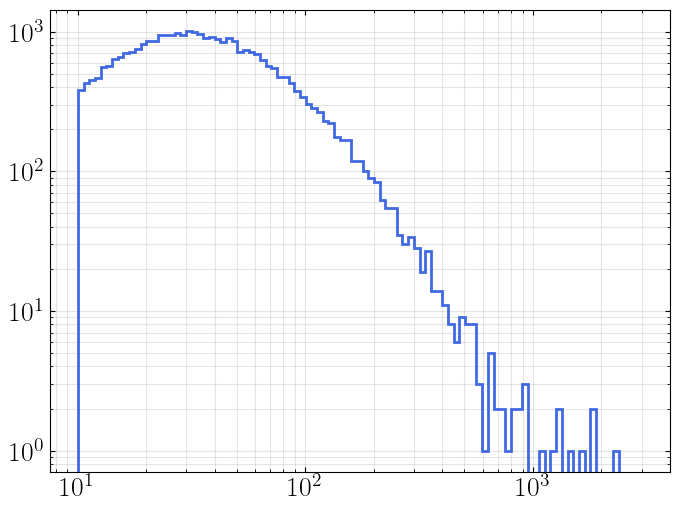

In [5]:
bins = np.geomspace(10,3000,100)
plt.hist(snr_detected, bins=bins, histtype='step', linewidth=2, color='royalblue');
plt.loglog()

[]

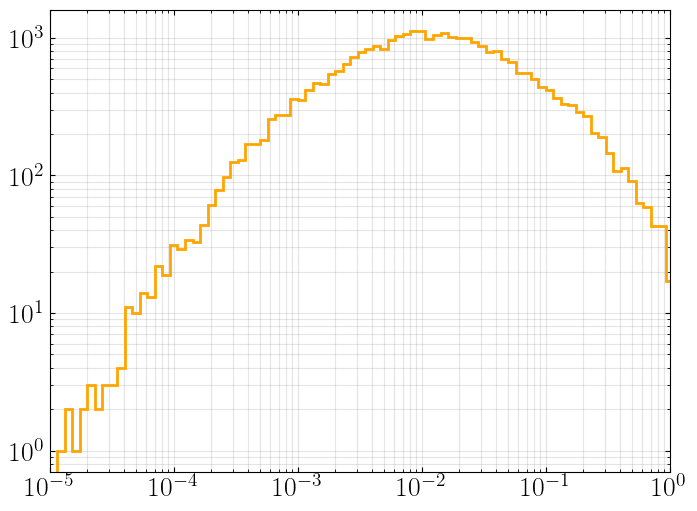

In [6]:
bins = np.geomspace(1e-5, 10, 100)
plt.hist(np.sqrt(cov_net[0,0]), bins=bins, histtype='step', linewidth=2, color='orange');
plt.xlim(1e-5, 1)
plt.loglog()

(0.01, 100)

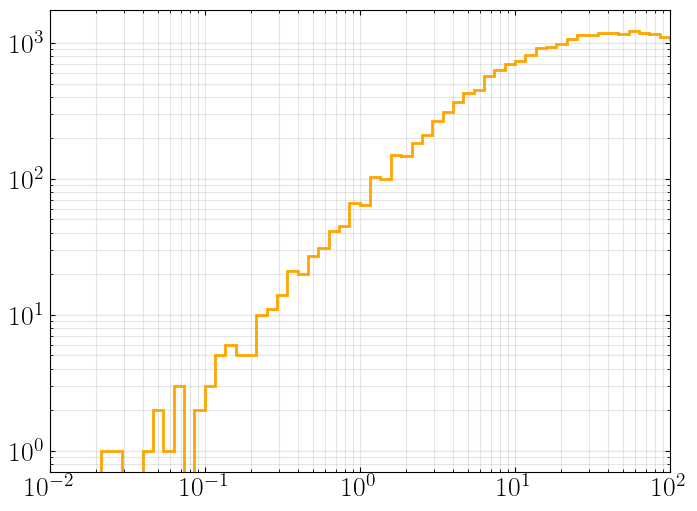

In [7]:
bins = np.geomspace(1e-2, 40000, 100)
plt.hist(sky_areas, bins=bins, histtype='step', linewidth=2, color='orange');
plt.loglog()
plt.xlim(1e-2, 100)

In [8]:
np.sum(sky_areas < 1)

322

In [9]:
len(sky_areas)

31378

In [13]:
catalog_file = "BBH_cat_1yr.h5"

events = h5py.File(catalog_file, 'r')

In [18]:
len(events['m1_src'][:][strict_mask])

31377